# Notebook 3 — SPMD / MPI Mental Model em Python

Este notebook fecha a sequência prática da aula integrada de:

- balanceamento de carga,
- consistência de memória,
- OpenMP como modelo mental,
- MPI / SPMD na prática.

## Objetivo

Demonstrar, em estilo **SPMD (Single Program, Multiple Data)**, como múltiplos processos:

1. executam o **mesmo programa**;
2. recebem **fatias diferentes dos dados**;
3. produzem resultados locais;
4. participam de uma **redução final** para formar o resultado global.

## Ideia central

Vamos simular um cenário típico de HPC:

- um vetor de tarefas com custos desiguais;
- vários processos executando o mesmo worker;
- comparação entre particionamento em **blocos** e **cíclico**;
- medição de tempo, balanceamento e speedup.

> Mensagem-chave: em SPMD, o programa é o mesmo para todos; o que muda é o **pedaço do dado** e o **tempo local de execução**.


In [ ]:
import math
import time
import statistics
from multiprocessing import Process, Queue
from collections import defaultdict

import matplotlib.pyplot as plt


## 1. Construindo a carga de trabalho

Usaremos tarefas com pesos variáveis para tornar o problema mais interessante.

Esse tipo de situação aparece quando:

- arquivos têm tamanhos diferentes;
- amostras exigem pré-processamentos desiguais;
- partes do dataset têm custo computacional heterogêneo.


In [2]:
def gerar_tarefas_spmd():
    import random

    random.seed(42)

    tarefas_temp = []

    # Muitas tarefas leves (simulando pré-processamento simples)
    tarefas_temp += [random.randint(2, 10) for _ in range(150)]

    # Algumas tarefas médias
    tarefas_temp += [random.randint(40, 55) for _ in range(30)]

    # Poucas tarefas MUITO pesadas espalhadas
    tarefas_temp += [random.randint(100, 200) for _ in range(10)]

    # 🔥 Embaralhar apenas o final
    inicio_shuffle = 90
    sublista = tarefas_temp[inicio_shuffle:]
    random.shuffle(sublista)
    tarefas_temp[inicio_shuffle:] = sublista

    return tarefas_temp

tarefas = gerar_tarefas_spmd()
len(tarefas), tarefas[:12]


(190, [3, 2, 6, 5, 5, 4, 3, 10, 3, 8, 2, 2])

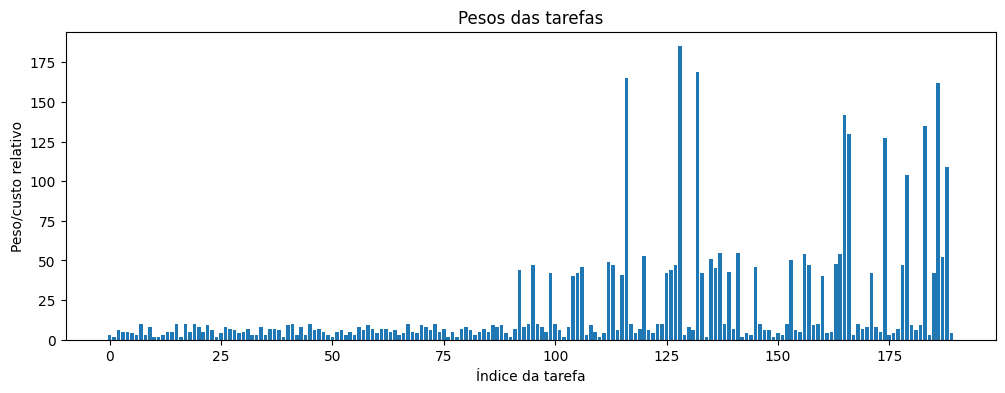

In [3]:
plt.figure(figsize=(12, 4))
plt.bar(range(len(tarefas)), tarefas)
plt.title("Pesos das tarefas")
plt.xlabel("Índice da tarefa")
plt.ylabel("Peso/custo relativo")
plt.show()


## 2. Função que simula computação local

Cada tarefa representa uma unidade de trabalho CPU-bound.
O custo cresce proporcionalmente ao peso.


In [ ]:
def computar_tarefa(peso: int) -> float:
    acc = 0.0
    repeticoes = peso * 110_000
    for i in range(1, repeticoes):
        acc += math.sqrt(i % 991) * math.cos(i % 360)
    return acc


## 3. Baseline sequencial

Antes do paralelo, medimos a versão sequencial.
Esse valor servirá como referência para speedup.


In [5]:
def executar_sequencial(tarefas):
    inicio = time.perf_counter()
    resultados = [computar_tarefa(t) for t in tarefas]
    total = sum(resultados)
    fim = time.perf_counter()
    return {
        "resultado_global": total,
        "wall_time": fim - inicio,
        "n_tarefas": len(tarefas)
    }

baseline = executar_sequencial(tarefas)
baseline


{'resultado_global': 36060995.44255187,
 'wall_time': 137.21125759999995,
 'n_tarefas': 190}

## 4. O que significa SPMD aqui?

No modelo SPMD:

- todos os processos executam o **mesmo worker**;
- cada processo conhece seu **rank**;
- o rank define qual fatia dos dados será processada;
- ao final, resultados locais são agregados.

Isso é a essência do estilo MPI, mesmo que aqui estejamos usando Python puro para simulação didática.


In [6]:
def particionar_blocos(dados, world_size):
    n = len(dados)
    tamanho = math.ceil(n / world_size)
    partes = []
    for i in range(world_size):
        inicio = i * tamanho
        fim = min((i + 1) * tamanho, n)
        partes.append(dados[inicio:fim])
    return partes


def particionar_ciclico(dados, world_size):
    partes = [[] for _ in range(world_size)]
    for i, item in enumerate(dados):
        partes[i % world_size].append(item)
    return partes


## 5. Visualizando blocos vs cíclico

A distribuição dos dados é uma das decisões mais importantes em SPMD.


In [7]:
world_size = 4
blocos = particionar_blocos(tarefas, world_size)
ciclico = particionar_ciclico(tarefas, world_size)

blocos, ciclico


([[3,
   2,
   6,
   5,
   5,
   4,
   3,
   10,
   3,
   8,
   2,
   2,
   3,
   5,
   5,
   10,
   2,
   10,
   5,
   10,
   8,
   5,
   9,
   6,
   2,
   4,
   8,
   7,
   6,
   4,
   5,
   7,
   3,
   3,
   8,
   3,
   7,
   7,
   6,
   2,
   9,
   10,
   3,
   8,
   3,
   10,
   6,
   7],
  [5,
   3,
   2,
   5,
   6,
   3,
   5,
   3,
   8,
   6,
   9,
   7,
   4,
   7,
   7,
   5,
   6,
   3,
   4,
   10,
   5,
   4,
   9,
   8,
   6,
   10,
   5,
   7,
   2,
   5,
   2,
   7,
   8,
   6,
   3,
   5,
   7,
   5,
   9,
   8,
   9,
   4,
   2,
   7,
   44,
   8,
   10,
   47],
  [10,
   8,
   5,
   42,
   10,
   6,
   2,
   8,
   40,
   42,
   46,
   3,
   9,
   5,
   2,
   4,
   49,
   47,
   6,
   41,
   165,
   10,
   4,
   7,
   53,
   6,
   4,
   10,
   10,
   42,
   44,
   47,
   185,
   3,
   8,
   6,
   169,
   42,
   2,
   51,
   45,
   55,
   10,
   43,
   7,
   55,
   2,
   4],
  [3,
   46,
   10,
   6,
   6,
   2,
   4,
   3,
   10,
   50,
   6,
   5,
   54,
   47,
   

In [8]:
def resumo_partes(partes):
    return [
        {
            "rank": i,
            "n_tarefas": len(p),
            "carga_total": sum(p),
            "tarefas": p
        }
        for i, p in enumerate(partes)
    ]

res_blocos = resumo_partes(blocos)
res_ciclico = resumo_partes(ciclico)

res_blocos, res_ciclico


([{'rank': 0,
   'n_tarefas': 48,
   'carga_total': 269,
   'tarefas': [3,
    2,
    6,
    5,
    5,
    4,
    3,
    10,
    3,
    8,
    2,
    2,
    3,
    5,
    5,
    10,
    2,
    10,
    5,
    10,
    8,
    5,
    9,
    6,
    2,
    4,
    8,
    7,
    6,
    4,
    5,
    7,
    3,
    3,
    8,
    3,
    7,
    7,
    6,
    2,
    9,
    10,
    3,
    8,
    3,
    10,
    6,
    7]},
  {'rank': 1,
   'n_tarefas': 48,
   'carga_total': 360,
   'tarefas': [5,
    3,
    2,
    5,
    6,
    3,
    5,
    3,
    8,
    6,
    9,
    7,
    4,
    7,
    7,
    5,
    6,
    3,
    4,
    10,
    5,
    4,
    9,
    8,
    6,
    10,
    5,
    7,
    2,
    5,
    2,
    7,
    8,
    6,
    3,
    5,
    7,
    5,
    9,
    8,
    9,
    4,
    2,
    7,
    44,
    8,
    10,
    47]},
  {'rank': 2,
   'n_tarefas': 48,
   'carga_total': 1474,
   'tarefas': [10,
    8,
    5,
    42,
    10,
    6,
    2,
    8,
    40,
    42,
    46,
    3,
    9,
    5,
    

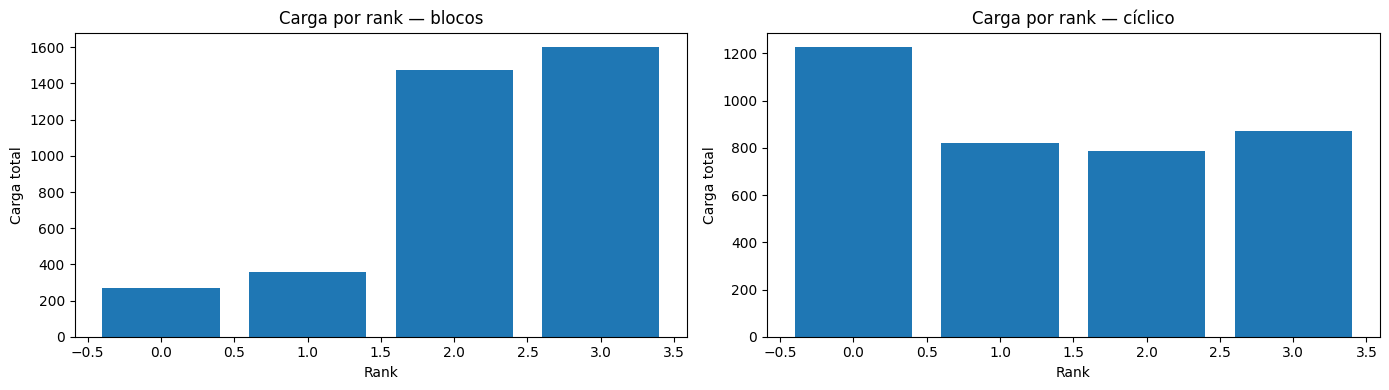

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar([r["rank"] for r in res_blocos], [r["carga_total"] for r in res_blocos])
axes[0].set_title("Carga por rank — blocos")
axes[0].set_xlabel("Rank")
axes[0].set_ylabel("Carga total")

axes[1].bar([r["rank"] for r in res_ciclico], [r["carga_total"] for r in res_ciclico])
axes[1].set_title("Carga por rank — cíclico")
axes[1].set_xlabel("Rank")
axes[1].set_ylabel("Carga total")

plt.tight_layout()
plt.show()


## 6. Worker SPMD

Todos os processos executarão exatamente esta mesma função.

Isso é crucial: **não existe um código diferente para cada rank**.
O comportamento muda porque o rank recebe dados diferentes.


In [10]:
def worker_spmd(rank, world_size, fatia_local, output_queue):
    inicio = time.perf_counter()

    resultados_locais = [computar_tarefa(t) for t in fatia_local]
    soma_local = sum(resultados_locais)

    fim = time.perf_counter()

    output_queue.put({
        "rank": rank,
        "world_size": world_size,
        "n_tarefas": len(fatia_local),
        "carga_total": sum(fatia_local),
        "resultado_local": soma_local,
        "tempo_local": fim - inicio
    })


## 7. Executor SPMD

Esta função cria os processos, dispara a execução paralela e recolhe os resultados locais.


In [11]:
def executar_spmd(partes):
    world_size = len(partes)
    fila = Queue()
    processos = []

    inicio_global = time.perf_counter()

    for rank in range(world_size):
        p = Process(target=worker_spmd, args=(rank, world_size, partes[rank], fila))
        processos.append(p)
        p.start()

    saidas = [fila.get() for _ in range(world_size)]

    for p in processos:
        p.join()

    fim_global = time.perf_counter()

    saidas = sorted(saidas, key=lambda x: x["rank"])
    resultado_global = sum(item["resultado_local"] for item in saidas)

    return {
        "saidas": saidas,
        "resultado_global": resultado_global,
        "wall_time": fim_global - inicio_global
    }


## 8. Execução SPMD com particionamento em blocos


In [ ]:
exec_blocos = executar_spmd(blocos)
exec_blocos


## 9. Execução SPMD com particionamento cíclico


In [ ]:
exec_ciclico = executar_spmd(ciclico)
exec_ciclico


## 10. Validação da corretude

Em HPC, acelerar sem validar corretude é erro metodológico.
Vamos verificar se o resultado global paralelo coincide com o sequencial.


In [ ]:
def quase_iguais(a, b, tol=1e-6):
    return abs(a - b) < tol

print("Blocos correto? ", quase_iguais(baseline["resultado_global"], exec_blocos["resultado_global"]))
print("Cíclico correto?", quase_iguais(baseline["resultado_global"], exec_ciclico["resultado_global"]))


## 11. Comparando o tempo por rank

Em SPMD, o tempo total costuma ser fortemente influenciado pelo rank mais lento.

Esse rank vira o gargalo da rodada.


In [ ]:
tempos_blocos = [x["tempo_local"] for x in exec_blocos["saidas"]]
tempos_ciclico = [x["tempo_local"] for x in exec_ciclico["saidas"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar([x["rank"] for x in exec_blocos["saidas"]], tempos_blocos)
axes[0].set_title("Tempo local por rank — blocos")
axes[0].set_xlabel("Rank")
axes[0].set_ylabel("Tempo (s)")

axes[1].bar([x["rank"] for x in exec_ciclico["saidas"]], tempos_ciclico)
axes[1].set_title("Tempo local por rank — cíclico")
axes[1].set_xlabel("Rank")
axes[1].set_ylabel("Tempo (s)")

plt.tight_layout()
plt.show()


## 12. Speedup e eficiência

Vamos calcular métricas clássicas.


In [ ]:
def metricas(tempo_seq, tempo_par, world_size):
    speedup = tempo_seq / tempo_par
    eficiencia = speedup / world_size
    return speedup, eficiencia

speedup_blocos, eficiencia_blocos = metricas(baseline["wall_time"], exec_blocos["wall_time"], world_size)
speedup_ciclico, eficiencia_ciclico = metricas(baseline["wall_time"], exec_ciclico["wall_time"], world_size)

print(f"Sequencial: {baseline['wall_time']:.4f} s")
print(f"SPMD blocos:  {exec_blocos['wall_time']:.4f} s | speedup={speedup_blocos:.3f} | eficiência={eficiencia_blocos:.3f}")
print(f"SPMD cíclico: {exec_ciclico['wall_time']:.4f} s | speedup={speedup_ciclico:.3f} | eficiência={eficiencia_ciclico:.3f}")


In [ ]:
labels = ["Sequencial", "SPMD blocos", "SPMD cíclico"]
tempos = [baseline["wall_time"], exec_blocos["wall_time"], exec_ciclico["wall_time"]]

plt.figure(figsize=(8, 4))
plt.bar(labels, tempos)
plt.title("Tempo total: sequencial vs SPMD")
plt.ylabel("Tempo (s)")
plt.show()


## 13. Redução final: o papel do collect/reduce

Nosso `resultado_global = soma(resultados_locais)` representa uma **redução**.

Em MPI real, isso costuma aparecer como operações como:

- `reduce`
- `all-reduce`
- `gather`

Aqui a ideia principal é:

1. cada rank produz uma resposta parcial;
2. o sistema combina essas respostas em um valor global.


In [ ]:
resumo_exec_blocos = [
    (x["rank"], x["n_tarefas"], x["carga_total"], round(x["tempo_local"], 4))
    for x in exec_blocos["saidas"]
]
resumo_exec_ciclico = [
    (x["rank"], x["n_tarefas"], x["carga_total"], round(x["tempo_local"], 4))
    for x in exec_ciclico["saidas"]
]

print("Resumo SPMD - blocos:")
for linha in resumo_exec_blocos:
    print(linha)

print("\nResumo SPMD - cíclico:")
for linha in resumo_exec_ciclico:
    print(linha)


## 14. Interpretação técnica

### O que este notebook mostra?

- O **mesmo programa** pode ter comportamentos diferentes por rank.
- O **particionamento dos dados** altera o balanceamento de carga.
- O **tempo total** depende do processo mais lento.
- O modelo SPMD é natural para clusters, MPI e treino distribuído.

### Ligação com IA

No treinamento distribuído:

- cada worker/GPU processa um mini-batch diferente;
- todos executam o mesmo loop de treino;
- gradientes locais são reduzidos/aglomerados;
- comunicação e sincronização afetam o ganho real.


## 15. Ligação com os notebooks anteriores

### Notebook 1
Mostrou que **balancear carga** é essencial.

### Notebook 2
Deve ter mostrado o modelo mental de **OpenMP / memória compartilhada / paralelismo local**.

### Notebook 3 (este)
Mostra o lado **SPMD / MPI / memória distribuída / redução global**.

> Em resumo: OpenMP organiza o paralelismo local.  
> SPMD/MPI organiza o paralelismo distribuído.


## 16. Exercícios propostos

### Exercício 1
Altere o número de ranks para `2`, `4` e `8`.  
O speedup cresce linearmente?

### Exercício 2
Crie uma carga ainda mais irregular e compare:
- blocos;
- cíclico.

### Exercício 3
Implemente uma estratégia de particionamento **gulosa balanceada** e compare com o cíclico.

### Exercício 4
Explique por que o modelo SPMD pode escalar bem e, mesmo assim, não apresentar ganho linear em aplicações reais de IA.


## 17. Síntese final

Este notebook materializa a lógica de SPMD:

- um único programa;
- múltiplos processos;
- múltiplos dados;
- resultados locais;
- redução final.

Ele também reforça a principal lição de HPC da aula:

> paralelismo eficiente não depende apenas de “usar mais processos”,  
> mas de **decomposição correta, balanceamento e custo de comunicação**.
